# Fully-connected Neural Network

Purely linear regressions aren’t able handle complex nonlinear relationships between predictors and target variables - for that kind of data we can use neural networks! Regular neural networks simply provide point estimates, but Bayesian neural networks (BNNs) give us both estimates and uncertainty information. BNNs also have strong regularization “built-in” (which comes from not only the priors, but also from from the sampling performed during stochastic variational inference). This makes it much harder for BNNs to overfit than regular neural networks.

Let’s create some nonlinear data to test our neural networks on.

I0000 00:00:1789865186.045839    2735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789865186.046317    2735 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789865186.088559    2735 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789865187.953053    2735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

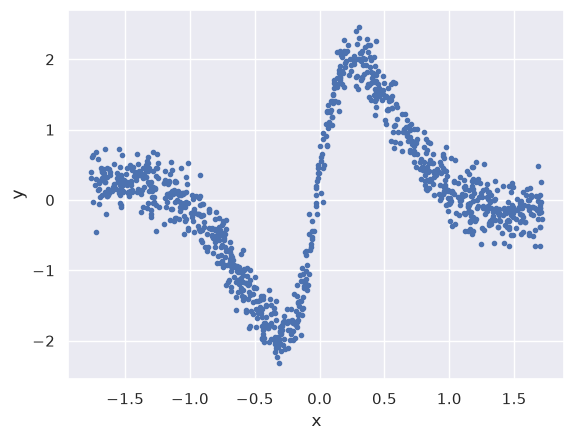

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

import probflow as pf

sns.set_theme()

# Helper functions
rand = lambda *x: np.random.rand(*x).astype("float32")
randn = lambda *x: np.random.randn(*x).astype("float32")
zscore = lambda x: (x - np.mean(x, axis=0)) / np.std(x, axis=0)

# Create the data
N = 1024
x = 10 * rand(N, 1) - 5
y = np.sin(x) / (1 + x * x) + 0.05 * randn(N, 1)

# Normalize
x = zscore(x)
y = zscore(y)

# Plot it
plt.plot(x, y, ".")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Building a Neural Network Manually

First we'll see how to manually create a Bayesian neural network with ProbFlow
from "scratch", to illustrate how to use the `pf.Module` class, and to see
why it's so handy to be able to define components from which you can build a
larger model.  Then later we'll use ProbFlow's pre-built modules which make
creating neural networks even easier.

Let's create a module which represents just a single fully-connected layer (aka
a "dense" layer).  This layer takes a vector $\mathbf{x}$ (of length
$N_i$), and outputs a vector of length $N_o$.  It multiplies the
input by its weights ($\mathbf{W}$, a $N_i \times N_o$ matrix of
learnable parameters), and adds a bias ($\mathbf{b}$, a
$N_o$-length vector of learnable parameters).

$$
\text{DenseLayer}(\mathbf{x}) = \mathbf{x}^\top \mathbf{W} + \mathbf{b}
$$

To use ProbFlow to create a module which represents this layer and creates and
keeps track of the weight and bias parameters, create a class which inherits
`pf.Module`:

In [ ]:
class DenseLayer(pf.Module):
    def __init__(self, d_in: int, d_out: int):
        self.w = pf.Parameter([d_in, d_out])
        self.b = pf.Parameter([1, d_out])

    def __call__(self, x):
        return x @ self.w() + self.b()

Side note: in `__call__` we’ve used `@`, the [infix operator for matrix multiplication](https://docs.python.org/3/whatsnew/3.5.html#whatsnew-pep-465).

Having defined a single layer, it’s much easier to define another `Module` which stacks several of those layers together. This module will represent an entire sub-network of sequential fully connected layers, with ReLU activation functions in between each (but no activation after the final layer). In `__init__`, this new module creates and contains several of the `DenseLayer` modules we defined above.

In [ ]:
class DenseNetwork(pf.Module):
    def __init__(self, dims: list[int]):
        Nl = len(dims) - 1  # number of layers
        self.layers = [DenseLayer(dims[i], dims[i + 1]) for i in range(Nl)]
        self.activations = (Nl - 1) * [tf.nn.relu] + [lambda x: x]

    def __call__(self, x):
        for i in range(len(self.activations)):
            x = self.layers[i](x)
            x = self.activations[i](x)
        return x

The first thing to notice here is that Modules can contain other Modules! This allows you to construct models using hierarchical building blocks, making testing and debugging of your models much easier, and encourages code reuse.

Also note that we’ve used TensorFlow (or PyTorch) code within the model! ProbFlow lets you mix and match ProbFlow operations and objects with operations from the backend you’ve selected.

Finally, we can create an actual Model which uses the network Module we’ve just created. This model consists of a normal distribution whose mean is predicted by the neural network. Note that while the `__call__` methods of the Modules above returned tensors, the `__call__` method of the Model below returns a probability distribution!

In [ ]:
class DenseRegression(pf.ContinuousModel):
    def __init__(self, dims):
        self.net = DenseNetwork(dims)
        self.s = pf.ScaleParameter([1, 1])

    def __call__(self, x):
        return pf.Normal(self.net(x), self.s())

Then we can instantiate the model. We’ll create a fully-connected Bayesian neural network with two hidden layers, each having 32 units. The first element of the list passed to the constructor is the number of features (in this case just one: $x$), and the last element is the number of target dimensions (in this case also just one: $y$).

In [5]:
model = DenseRegression([1, 32, 32, 1])

E0000 00:00:1789865188.453187    2735 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Then we can fit the network to the data!

In [6]:
model.fit(x, y, epochs=1000, lr=0.02)

The fit network can make predictions:

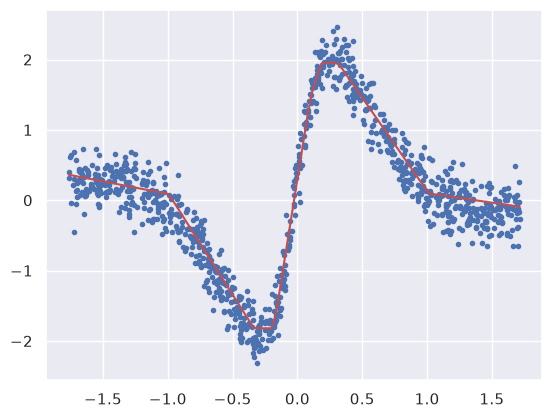

In [7]:
# Test points to predict
x_test = np.linspace(min(x), max(x), 101).astype("float32").reshape(-1, 1)

# Predict them!
preds = model.predict(x_test)

# Plot it
plt.plot(x, y, ".", label="Data")
plt.plot(x_test, preds, "r", label="Predictions")

And because this is a Bayesian neural network, it also gives us uncertainty estimates. For example, we can compute the 95% posterior predictive distribution intervals:

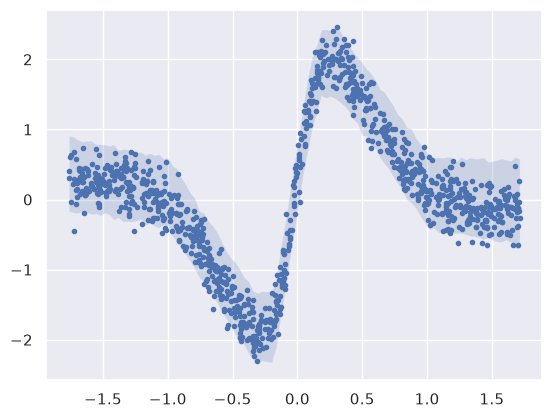

In [8]:
# Compute 95% confidence intervals
lb, ub = model.predictive_interval(x_test, ci=0.95)

# Plot em!
plt.fill_between(x_test[:, 0], lb[:, 0], ub[:, 0], alpha=0.2, label="95% ci")
plt.plot(x, y, ".", label="Data")

## Using the Dense and Sequential Modules

ProbFlow comes with some ready-made modules for creating fully-connected neural networks. The `Dense` module handles creating the weight and bias parameters, and the `Sequential` module takes a list of modules or callables and pipes the output of each into the input of the next.

Using these two modules, we can define the same neural network as above much more easily:

In [ ]:
class DenseRegression(pf.Model):
    def __init__(self, d_in: int, d_out: int):
        self.net = pf.Sequential(
            [
                pf.Dense(d_in, 32),
                tf.nn.relu,
                pf.Dense(32, 32),
                tf.nn.relu,
                pf.Dense(32, d_out),
            ]
        )
        self.s = pf.ScaleParameter()

    def __call__(self, x):
        return pf.Normal(self.net(x), self.s())

Then we can instantiate and fit the network similarly to before:

In [10]:
model = DenseRegression(d_in=1, d_out=1)
model.fit(x, y)

## Using the DenseNetwork Module

The `DenseNetwork` module can be used to automatically create sequential models of Dense layers with activations in between (by default, rectified linear activations). Just pass the number of dimensions per dense layer as a list, and `DenseNetwork` will create a fully-connected neural network with the corresponding number of units, rectified linear activation functions in between, and no activation function after the final layer.

For example, to create the same model as above with `DenseNetwork` (but without having to write the component modules yourself):

In [ ]:
class DenseRegression(pf.Model):
    def __init__(self, dims: list[int]):
        self.net = pf.DenseNetwork(dims)
        self.s = pf.ScaleParameter()

    def __call__(self, x):
        return pf.Normal(self.net(x), self.s())


model = DenseRegression(dims=[1, 32, 32, 1])
model.fit(x, y)

## Using the DenseRegression or DenseClassifier applications

The `DenseNetwork` module automatically creates sequential dense layers, but it doesn’t include an observation distribuiton. To create the same model as before (a multilayer network which predicts the mean of a normally-distributed observation distribution), use the `DenseRegression` application:

In [12]:
model = pf.DenseRegression([1, 32, 32, 1])
model.fit(x, y)

To instead use a dense network to perform classification (where the observation distribution is a categorical distribtuion instead of a normal distribution), use the DenseClassifier application.

For example, to create a Bayesian neural network (with two hidden layers containing 32 units each) to perform classification between Nc categories:

In [14]:
# Nf = number of features
# Nc = number of categories in target
# model = pf.DenseClassifier([Nf, 32, 32, Nc])
# model.fit(x, y)